In [1]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# Set style
# plt.style.use('seaborn-v0_8-whitegrid')
# sns.set_palette('husl')
sns.set_style("ticks")

## 1. Fetch Data from W&B

Configure your W&B project and run details below:

In [2]:
# W&B Configuration
WANDB_PROJECT = "exact"
WANDB_ENTITY = "assistive-autonomy"

# Fetch specific run by name or ID
RUN_NAME = "activity_20260112_133637"  # e.g., "verbs_20251223_131604" or None to use latest
RUN_ID = "7cur3i6e"    # e.g., "1c5f755e" or None

In [3]:
def fetch_wandb_data(project: str, entity: str, run_name: str = None, run_id: str = None):
    """
    Fetch anomaly detection data from W&B.
    
    Returns:
        dict with activities, score_matrix, auc values, separation values
    """
    api = wandb.Api()
    
    # Find the run
    if run_id:
        run = api.run(f"{entity}/{project}/{run_id}")
    else:
        # Get runs and filter
        runs = api.runs(f"{entity}/{project}")
        if run_name:
            runs = [r for r in runs if r.name == run_name]
        if not runs:
            raise ValueError(f"No runs found matching criteria")
        run = runs[0]  # Most recent
    
    print(f"Found run: {run.name} (ID: {run.id})")
    print(f"State: {run.state}")
    
    # Get summary metrics
    summary = run.summary._json_dict
    
    # Fetch the results table (per-activity metrics)
    results_df = None
    try:
        for artifact in run.logged_artifacts():
            if artifact.type == "run_table":
                for file in artifact.files():
                    if "results_table" in file.name:
                        table_path = artifact.download()
                        table_file = Path(table_path) / file.name
                        with open(table_file) as f:
                            table_data = json.load(f)
                        results_df = pd.DataFrame(table_data["data"], columns=table_data["columns"])
                        print(f"Loaded results_table with {len(results_df)} activities")
                        break
    except Exception as e:
        print(f"Could not fetch results_table from artifacts: {e}")
    
    # Fetch the separability matrix table
    matrix_df = None
    try:
        for artifact in run.logged_artifacts():
            if artifact.type == "run_table":
                for file in artifact.files():
                    if "separability_matrix" in file.name:
                        table_path = artifact.download()
                        table_file = Path(table_path) / file.name
                        with open(table_file) as f:
                            table_data = json.load(f)
                        matrix_df = pd.DataFrame(table_data["data"], columns=table_data["columns"])
                        print(f"Loaded separability_matrix ({len(matrix_df)}x{len(matrix_df)})")
                        break
    except Exception as e:
        print(f"Could not fetch separability_matrix from artifacts: {e}")
    
    return {
        "run": run,
        "summary": summary,
        "config": run.config,
        "results_df": results_df,
        "matrix_df": matrix_df,
    }


def parse_wandb_data(wandb_data: dict):
    """
    Parse W&B data into the format expected by plotting functions.
    
    Returns:
        dict with activities, score_matrix, auc_matrix, separation_vector, n_models
    """
    results_df = wandb_data["results_df"]
    matrix_df = wandb_data["matrix_df"]
    summary = wandb_data["summary"]
    
    # Get activities from matrix (first column is model_trained_on)
    activities = matrix_df["model_trained_on"].tolist()
    n = len(activities)
    
    # Build score matrix from matrix_df
    score_matrix = np.zeros((n, n))
    for i, row in matrix_df.iterrows():
        for j, act in enumerate(activities):
            val = row[act]
            score_matrix[i, j] = val if val is not None else np.nan
    
    # Build separation vector from results_df
    separation_vector = np.full(n, np.nan)
    for i, act in enumerate(activities):
        match = results_df[results_df["activity"] == act]
        if len(match) > 0:
            val = match["separation"].iloc[0]
            separation_vector[i] = val if val is not None else np.nan
    
    # Build AUC matrix (only diagonal from results_df)
    auc_matrix = np.full((n, n), np.nan)
    for i, act in enumerate(activities):
        match = results_df[results_df["activity"] == act]
        if len(match) > 0:
            val = match["auc"].iloc[0]
            auc_matrix[i, i] = val if val is not None else np.nan
    
    n_models = summary.get("n_models", n)
    
    return {
        "activities": activities,
        "score_matrix": score_matrix,
        "auc_matrix": auc_matrix,
        "separation_vector": separation_vector,
        "n_models": n_models,
    }

In [4]:
# Fetch data from W&B
wandb_data = fetch_wandb_data(WANDB_PROJECT, WANDB_ENTITY, RUN_NAME, RUN_ID)

print("\nSummary metrics:")
for key in ["mean_auc", "std_auc", "mean_separation", "std_separation", "n_models"]:
    if key in wandb_data["summary"]:
        val = wandb_data["summary"][key]
        if isinstance(val, float):
            print(f"  {key}: {val:.4f}")
        else:
            print(f"  {key}: {val}")

# Parse W&B data into the format for plotting
data = parse_wandb_data(wandb_data)
print(f"\nLoaded {data['n_models']} models for {len(data['activities'])} activities")
print(f"Activities: {data['activities']}")

Found run: activity_20260112_133637 (ID: 7cur3i6e)
State: finished


wandb:   1 of 1 files downloaded.  


Loaded results_table with 6 activities


wandb:   1 of 1 files downloaded.  


Loaded separability_matrix (6x6)

Summary metrics:
  mean_auc: 0.5046
  std_auc: 0.0756
  mean_separation: 0.2560
  std_separation: 0.4745
  n_models: 6

Loaded 6 models for 6 activities
Activities: ['cleaning', 'cooking', 'experimental procedure', 'getting ready', 'other_annot', 'preparing ingredients']


## 2. Customizable Separability Matrix Plot

Adjust colors, fonts, and styling below:

In [5]:
# === PLOT CONFIGURATION ===

mm = 1 / 25.4     # conversion from millimeters to inches
cm = 1 / 2.54     # conversion from centimeters to inches
pt = 1 / 72.27    # conversion from points to inches

# The values below are obtained from LaTeX, using \the\columnwidth and \the\textwidth
PAPER_COLUMN = 347.12361  # points
PAPER_TEXTWIDTH = 47.12361  # points

plot_width = PAPER_COLUMN * pt   # We use the constant to convert points in inches
plot_height = PAPER_COLUMN * pt  # We use this to convert the size to inches, as matplotlib uses
RESOLUTION = 150                  # 'DPI', but actually PPI


# Figure settings
FIGSIZE = (plot_width, plot_height)

# Color palette for heatmap
# Options: 'RdYlGn', 'viridis', 'plasma', 'coolwarm', 'RdBu_r', 'YlGnBu'
CMAP = 'viridis'

# Font settings
LABEL_FONTSIZE = 11
TICK_FONTSIZE = 11
ANNOT_FONTSIZE = 11

# Annotation settings
SHOW_VALUES = True           # Show numeric values in cells
VALUE_FORMAT = '.1f'         # Format for values

In [6]:
def plot_separability_matrix(
    activities: list,
    score_matrix: np.ndarray,
    cmap: str = CMAP,
    figsize: tuple = FIGSIZE,
    show_values: bool = SHOW_VALUES,
    save_path: str = None,
):
    """
    Plot separability matrix as a customizable heatmap.
    
    The matrix shows how each model (row) scores each activity (column).
    Diagonal should be highest for good separability.
    
    Note: Colors are based on row-normalized values (0-1) for visual comparison,
    but cell annotations show actual log-probability values.
    """
    n = len(activities)
    
    # Wrap activity labels by replacing spaces with newlines
    wrapped_activities = [act.replace(' ', '\n') for act in activities]
    wrapped_activities = [act.replace('_', '\n') for act in wrapped_activities]
    
    # Use original values for both coloring and annotation (no normalization)
    plot_matrix = score_matrix.copy()
    vmin, vmax = np.nanmin(plot_matrix), np.nanmax(plot_matrix)
    cbar_label = "NLL"
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create heatmap using seaborn for nicer styling
    mask = np.isnan(plot_matrix)
    
    sns.heatmap(
        plot_matrix,
        annot=score_matrix if show_values else False,  # Show original values
        fmt=VALUE_FORMAT if show_values else '',
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        mask=mask,
        square=True,
        linewidths=0.5,
        linecolor='white',
        cbar=True,
        cbar_kws={'label': cbar_label, 'shrink': 0.65},
        annot_kws={'size': ANNOT_FONTSIZE},
        ax=ax,
    )
    
    
    # Labels - use wrapped activities for better display
    ax.set_xticklabels(wrapped_activities, rotation=20, fontsize=TICK_FONTSIZE)
    ax.set_yticklabels(wrapped_activities, rotation=20, fontsize=TICK_FONTSIZE)
    ax.set_xlabel('Query action', fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_ylabel('Target action', fontsize=LABEL_FONTSIZE, fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=RESOLUTION, bbox_inches='tight', facecolor='white')
        print(f"Saved to: {save_path}")
    
    plt.show()
    return fig

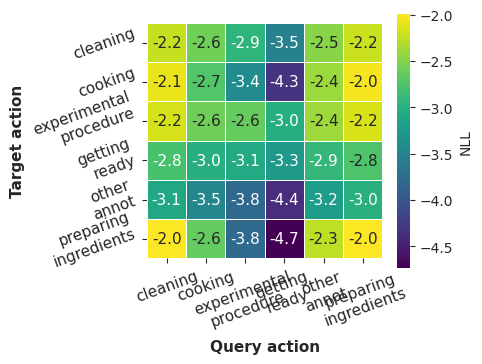

In [7]:
# Plot the separability matrix
fig = plot_separability_matrix(
    activities=data['activities'],
    score_matrix=data['score_matrix'],)

In [8]:
fig.set_tight_layout(True)
fig.savefig("anomaly.pdf")

## 3. Local Results — All Three Runs (1×3 Stacked Figure)

### How to read the AUROC separability matrix

Each row corresponds to a **normalising-flow model trained on one action class** (the *target* action); each column corresponds to the **query action** whose samples are scored by that model.

**Off-diagonal entry (i ≠ j)** — exact pairwise AUROC:
> *"Can model i assign higher log-probability to its own class-i samples than to class-j samples?"*

$$\text{AUROC}(i \to j) = P\!\left(\text{score}_{ii} > \text{score}_{ij}\right)$$

computed directly from the per-sample NLL scores collected during evaluation.

**Diagonal entry (i, i)** — overall AUROC of model i against all other classes pooled together (a summary of one row's discriminability).

**Interpreting cell values:**

| Value | Meaning |
|---|---|
| ≈ 1.0 | Model i near-perfectly separates its class from class j — the two score distributions barely overlap |
| ≈ 0.5 | Model i cannot distinguish its class from class j — the distributions heavily overlap |
| < 0.5 | Model i unexpectedly assigns *higher* log-probability to class j, indicating mode-collapse or cross-class confusion |

**Ideal pattern:** a strong separability matrix has **high values everywhere**, meaning every model confidently identifies its own class relative to each other class. A low off-diagonal entry $(i,j)$ flags that actions $i$ and $j$ produce similar motion patterns from model $i$'s perspective.


In [9]:
import json
import numpy as np
from pathlib import Path

RESULTS_ROOT = Path("../results/anomaly_detection")

# Each entry: (folder_name, display_title)
LOCAL_RUNS = [
    ("actions_20260303_194017",  "HumanAct12"),
    ("activity_20260303_183649", "ESK Activities"),
    ("verbs_20260303_163015",    "ESK Verbs"),
]

def load_local_run(folder: str | Path) -> dict:
    """Load an aggregated.json produced by anomaly_detection.py.

    The auc_matrix is now a full NxN pairwise AUROC matrix computed
    directly from per-sample scores during evaluation (no approximation).
    Entry (i, j) is the exact AUROC for model i distinguishing its own
    class i from class j.
    """
    path = RESULTS_ROOT / folder / "aggregated.json"
    with open(path) as f:
        raw = json.load(f)

    activities = raw["activities"]
    n = len(activities)

    def _mat(nested):
        return np.array(
            [[np.nan if (v != v or v is None) else v for v in row]
             for row in nested],
            dtype=float,
        )

    return {
        "activities":        activities,
        "score_matrix":      _mat(raw["score_matrix"]),
        "auc_matrix":        _mat(raw["auc_matrix"]),   # full NxN pairwise AUROC
        "separation_vector": np.array(
            [np.nan if (v != v or v is None) else v for v in raw["separation_vector"]],
            dtype=float,
        ),
        "n_models": raw.get("n_models", n),
    }

local_datasets = [(title, load_local_run(folder)) for folder, title in LOCAL_RUNS]
for title, d in local_datasets:
    print(f"{title}: {d['activities']}")
    print(f"  diagonal AUROC: {np.diag(d['auc_matrix']).round(3)}")


HumanAct12: ['drink', 'jump', 'run', 'throw', 'walk']
  diagonal AUROC: [0.393 0.803 0.491 0.312 0.696]
ESK Activities: ['cleaning', 'cooking', 'experimental procedure', 'getting ready', 'preparing ingredients']
  diagonal AUROC: [0.577 0.459 0.495 0.43  0.523]
ESK Verbs: ['Add', 'Carry', 'Cut', 'Move', 'Stir']
  diagonal AUROC: [0.502 0.484 0.082 0.546 0.687]


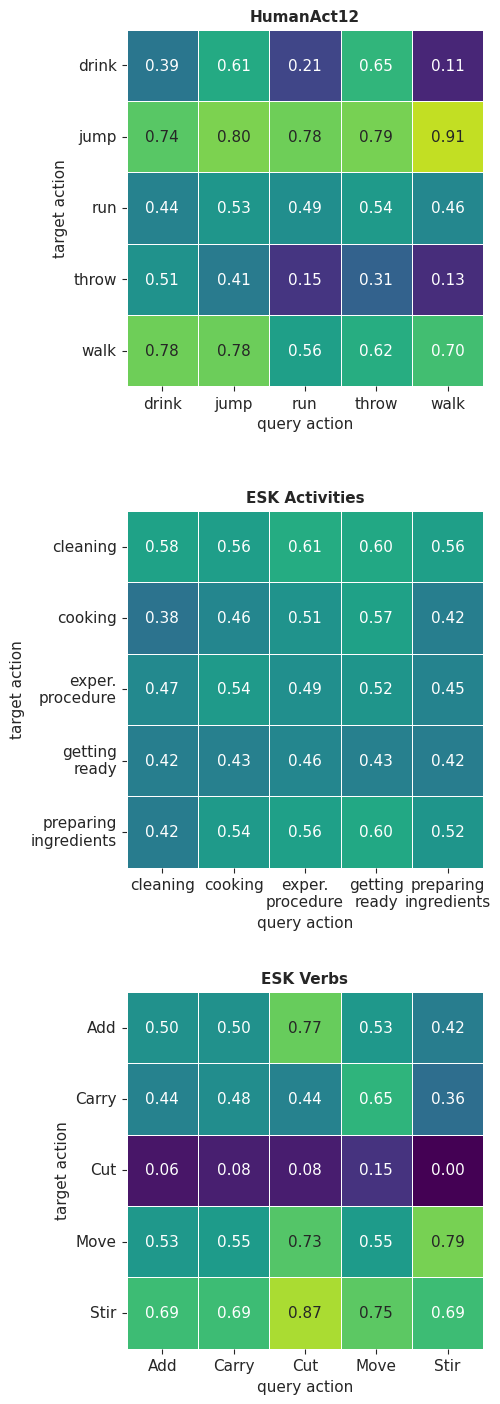

In [13]:
def plot_stacked_separability_matrices(
    datasets: list[tuple[str, dict]],
    cmap: str = "viridis",
    show_values: bool = SHOW_VALUES,
    show_cbar: bool = False,
    save_path: str = None,
):
    """
    Plot pairwise AUROC separability matrices for multiple runs stacked vertically.

    Entry (i, j) shows how well the model trained on activity i can distinguish
    activity-i samples from activity-j samples (exact AUROC in [0, 1]).
    The diagonal (i == j) is the self-separability of each model; values close
    to 1 mean the model confidently identifies its own class against every other.
    """
    n_runs = len(datasets)

    fig, axes = plt.subplots(
        n_runs, 1,
        figsize=(FIGSIZE[0], FIGSIZE[1] * n_runs),
    )
    if n_runs == 1:
        axes = [axes]

    for ax, (title, d) in zip(axes, datasets):
        activities = d["activities"]
        auc_matrix = d["auc_matrix"]   # full NxN pairwise AUROC
        n = len(activities)

        wrapped = [a.replace(" ", "\n").replace("_", "\n") for a in activities]
        if title == "ESK Activities":
            wrapped = [a.replace("experimental", "exper.") for a in wrapped]

        vmin, vmax = 0.0, 1.0
        mask = np.isnan(auc_matrix)

        sns.heatmap(
            auc_matrix,
            annot=auc_matrix if show_values else False,
            fmt=".2f" if show_values else "",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            mask=mask,
            square=True,
            linewidths=0.5,
            linecolor="white",
            cbar=show_cbar,
            cbar_kws={"label": "AUROC", "shrink": 1.0} if show_cbar else {},
            annot_kws={"size": ANNOT_FONTSIZE},
            ax=ax,
        )

        if show_cbar:
            cbar = ax.collections[0].colorbar
            cbar.ax.yaxis.set_major_locator(
                plt.matplotlib.ticker.MultipleLocator(0.25)
            )
            cbar.ax.yaxis.set_major_formatter(
                plt.matplotlib.ticker.FormatStrFormatter("%.2f")
            )

        ax.set_title(title, fontsize=LABEL_FONTSIZE, fontweight="bold", pad=6)
        ax.set_xticklabels(wrapped, rotation=0, fontsize=TICK_FONTSIZE)
        ax.set_yticklabels(wrapped, rotation=0, fontsize=TICK_FONTSIZE)
        ax.set_xlabel("query action", fontsize=LABEL_FONTSIZE)
        ax.set_ylabel("target action", fontsize=LABEL_FONTSIZE)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=RESOLUTION, bbox_inches="tight", facecolor="white")
        print(f"Saved to: {save_path}")

    plt.show()
    return fig


fig_stacked = plot_stacked_separability_matrices(local_datasets)
fig_stacked.savefig("anomaly.pdf", bbox_inches="tight")
